<a href="https://colab.research.google.com/github/nurbibybejsenbek-maker/coffeehouse-project/blob/main/ZS_6_Monte_Carlo_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- МОНТЕ-КАРЛО СИМУЛЯЦИЯСЫНЫҢ НӘТИЖЕСІ (30 тапсырма) ---
P50 (50% ықтималдық): 9 апта
P70 (70% ықтималдық): 10 апта
P85 (85% ықтималдық): 10 апта
P95 (95% ықтималдық): 11 апта


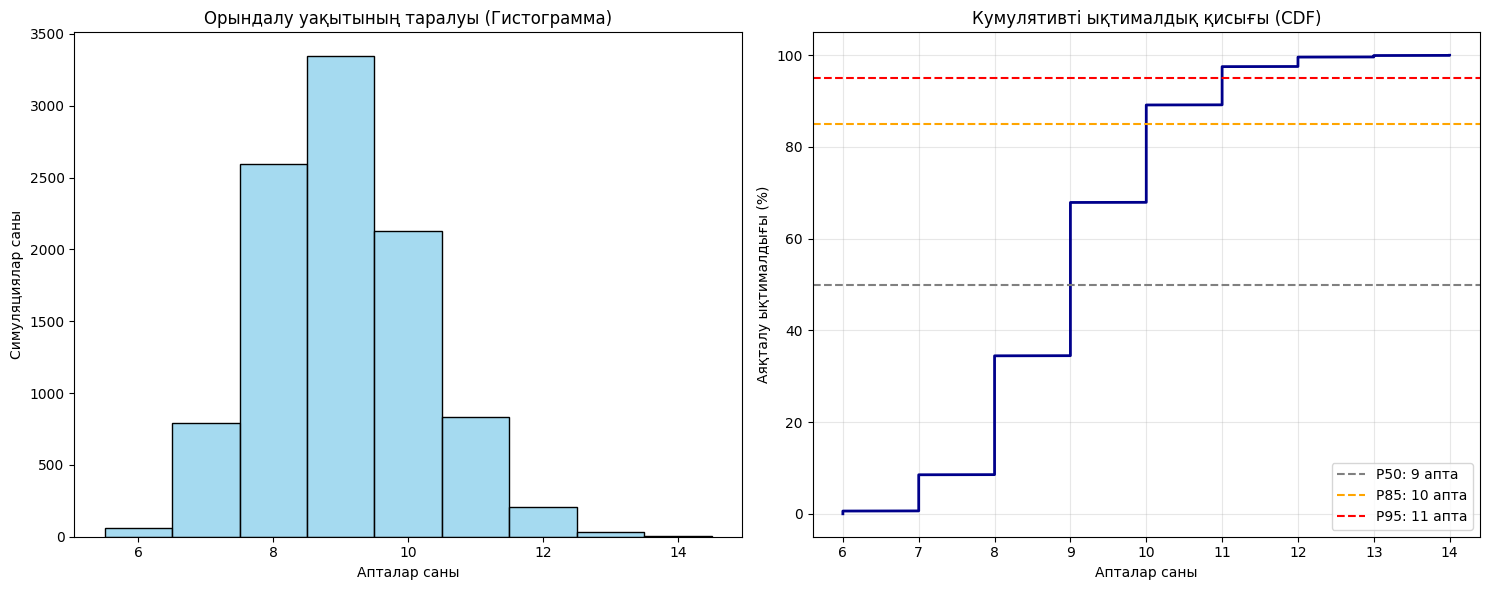

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Деректерді дайындау
# Тарихи Throughput деректері (аптасына бітетін тапсырмалар саны)
# Мысалы, соңғы 12 аптада біткен issues саны:
historical_throughput = [3, 5, 2, 4, 6, 3, 1, 4, 5, 2, 4, 3]

# Бэклогтағы қалған тапсырмалар саны (N)
backlog_size = 30

# Симуляция саны
num_simulations = 10000

# ---------------------------------------------------------
# 2. Монте-Карло симуляциясын жүргізу
completion_weeks = []

np.random.seed(42)  # Нәтиже қайталанатын болуы үшін

for _ in range(num_simulations):
    remaining_tasks = backlog_size
    weeks_count = 0

    while remaining_tasks > 0:
        # Тарихи деректерден кездейсоқ апталық throughput таңдаймыз
        weekly_done = np.random.choice(historical_throughput)
        remaining_tasks -= weekly_done
        weeks_count += 1

    completion_weeks.append(weeks_count)

# ---------------------------------------------------------
# 3. Перцентильдерді есептеу (P50, P70, P85, P95)
p50 = np.percentile(completion_weeks, 50)
p70 = np.percentile(completion_weeks, 70)
p85 = np.percentile(completion_weeks, 85)
p95 = np.percentile(completion_weeks, 95)

print(f"--- МОНТЕ-КАРЛО СИМУЛЯЦИЯСЫНЫҢ НӘТИЖЕСІ ({backlog_size} тапсырма) ---")
print(f"P50 (50% ықтималдық): {int(p50)} апта")
print(f"P70 (70% ықтималдық): {int(p70)} апта")
print(f"P85 (85% ықтималдық): {int(p85)} апта")
print(f"P95 (95% ықтималдық): {int(p95)} апта")

# ---------------------------------------------------------
# 4. Графиктерді салу (Gistogram & Cumulative Distribution)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Гистограмма
sns.histplot(completion_weeks, bins=range(min(completion_weeks), max(completion_weeks) + 2),
             kde=False, color='skyblue', ax=ax1, discrete=True)
ax1.set_title("Орындалу уақытының таралуы (Гистограмма)")
ax1.set_xlabel("Апталар саны")
ax1.set_ylabel("Симуляциялар саны")

# Кумулятивтік қисық (CDF)
sorted_weeks = np.sort(completion_weeks)
yvals = np.arange(len(sorted_weeks)) / float(len(sorted_weeks) - 1)

ax2.plot(sorted_weeks, yvals * 100, color='darkblue', linewidth=2)
ax2.axhline(50, color='gray', linestyle='--', label=f'P50: {int(p50)} апта')
ax2.axhline(85, color='orange', linestyle='--', label=f'P85: {int(p85)} апта')
ax2.axhline(95, color='red', linestyle='--', label=f'P95: {int(p95)} апта')

ax2.set_title("Кумулятивті ықтималдық қисығы (CDF)")
ax2.set_xlabel("Апталар саны")
ax2.set_ylabel("Аяқталу ықтималдығы (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()